## Pauli Correlation Encoding to reduce qubits requirements

The goal of this project is to use Pauli Correlation Encoding to encode optimization problems into few qubits.
We will compare classical solvers with quantum solvers, for the Max-Cut problem and for the Maximum Independent Set (MIS).

## What is the Pauli Encoding ?

 *Pauli Correlation Encoding*  is an approach designed to encode optimization problems into qubits with greater efficiency for quantum computation. PCE maps classical variables in optimization problems to multi-body Pauli-matrix correlations, resulting in a polynomial compression of the problem's space requirements. By employing PCE, the number of qubits needed for encoding is reduced, making it particularly advantageous for near-term quantum devices with limited qubit resources. Furthermore, it is analytically demonstrated that PCE inherently mitigates barren plateaus, offering super-polynomial resilience against this phenomenon. This built-in feature enables unprecedented performance in quantum optimization solvers.

## Requirements

Be sure you have the following installed:

* Qiskit SDK v1.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)


## Différents problème : 

## Max-cut : 
Le problème MaxCut est un défi d'optimisation combinatoire NP-difficile qui consiste à partitionner les sommets d'un graphe $G=(V, E)$ en deux sous-ensembles disjoints de telle sorte que la somme des poids des arêtes reliant ces deux ensembles soit maximale. Mathématiquement, on cherche à maximiser la fonction objective $\mathcal{V}(x) = \sum_{(i,j) \in E} W_{ij} (1 - x_i x_j)$, où $W_{ij}$ représente le poids de l'arête entre les sommets $i$ et $j$, et $x_i \in \{-1, 1\}$ indique l'appartenance de chaque sommet à l'une des deux partitions. Ce problème est fondamental car de nombreux défis industriels peuvent y être ramenés, mais son approximation au-delà d'un ratio de 0,941 est considérée comme calculatoirement impossible pour des algorithmes classiques en temps polynomial. L'approche par Encodage par Corrélations de Pauli (PCE) permet de s'attaquer à ce problème à grande échelle en compressant les $m$ variables de décision dans un nombre réduit de qubits $n$, offrant ainsi une voie prometteuse pour les dispositifs quantiques actuels.

## Maximal Independant Set :
## Maximum Independent Set (MIS) :
Le problème du Maximum Independent Set (MIS) consiste à trouver le plus grand sous-ensemble de sommets d'un graphe tel qu'aucun de ces sommets ne soit adjacent à un autre (aucune arête ne doit relier deux sommets du set). C'est un problème NP-difficile au cœur de nombreuses applications réelles, comme l'allocation de fréquences en télécommunications (deux antennes proches ne peuvent pas émettre sur la même fréquence sans interférence) ou la compression de données. 
Contrairement à des problèmes de routage, son évaluation est purement locale : la fonction de coût cherche à maximiser le nombre de nœuds choisis tout en appliquant une forte pénalité si deux nœuds connectés sont sélectionnés simultanément. Cette structure QUBO (Quadratic Unconstrained Binary Optimization) est particulièrement naturelle et bien adaptée à l'encodage PCE, permettant de compresser les variables dans un minimum de qubits tout en évitant des calculs classiques intermédiaires complexes.

## Choix du problème à résoudre :

Choisissez parmi "Max-Cut" et "MIS" le problème que vous souhaitez résoudre.

In [1]:
# problem = "Max-Cut"
problem = "MIS"

## Création de l'instance de résolution du problème
- soit on importe un graphe/arbre de son choix
- soit on utilise le générateur d'instance pour créer un graphe/arbre

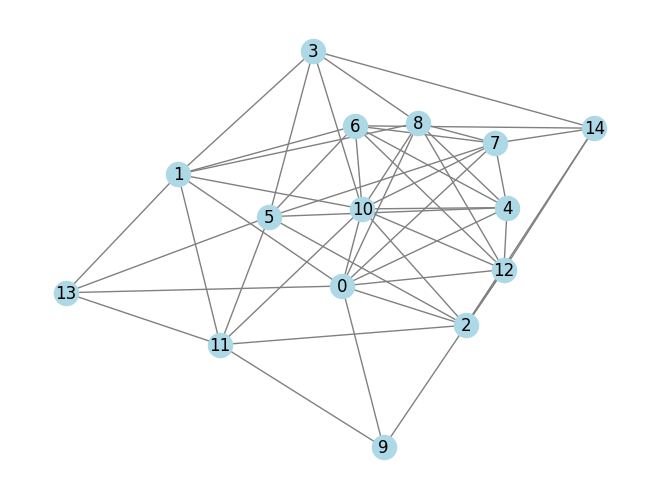

In [2]:
from instance_generator import graph_creation
import matplotlib.pyplot as plt
import networkx as nx
num_nodes = 15

instance = graph_creation(num_nodes)
nx.draw(instance, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

## Résolution classique : 

In [3]:
from classical_solvers import classical_solver

classical_cut_size, classical_partition = classical_solver(instance, problem)

Independent set: {2, 3, 4, 9, 13}


## Encodage de Pauli des noeuds du graphe : 

In [4]:
from variables_encoding import variables_encoding

num_qubits = 4

pce_groups = variables_encoding(num_nodes, num_qubits)

List X: [0, 3, 6, 9, 12]
List Y: [1, 4, 7, 10, 13]
List Z: [2, 5, 8, 11, 14]
[SparsePauliOp(['IIXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIXI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIYY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIYI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIZI'],
              coeffs=[1.+0.j])]


## Résolution quantique :

In [5]:
from quantum_solvers import solve_maxcut_pce, solve_mis_pce
from utils import calc_cut_size

if problem == "Max-Cut":
    results = solve_maxcut_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, max_iter=150)

    # Affichage des résultats 
    print(f"Partition 0 : {results['par0']}")
    print(f"Partition 1 : {results['par1']}")

    # Calcul de la taille du cut final
    cut_size = calc_cut_size(instance, results['par0'], results['par1'])
    print(f"Taille du Cut : {cut_size}")

elif problem == "MIS":
    results = solve_mis_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, reps=4, max_iter=300)

    # Affichage des résultats 
    print(f"Independent set : {results['independent_set']}")

    # Calcul de la taille de l'ensemble indépendant final
    independent_set_size = len(results['independent_set'])
    print(f"Taille de l'ensemble indépendant : {independent_set_size}")

Iter 0: 15.17728296577052
Iter 1: 15.041707684410344
Iter 2: 9.717558216330536
Iter 3: 7.571765023170263
Iter 4: 6.489139996491109
Iter 5: 11.65321527436739
Iter 6: 7.126151035956007
Iter 7: 7.113118629640372
Iter 8: 5.889175424781402
Iter 9: 6.110011152800983
Iter 10: 14.142440586465934
Iter 11: 4.074787896762035
Iter 12: 6.431627468834578
Iter 13: 5.941101502101339
Iter 14: 5.669553341527476
Iter 15: 6.5443454762839375
Iter 16: 6.684932443621289
Iter 17: 3.4477407726889444
Iter 18: 4.26419166461835
Iter 19: 3.0056854729492857
Iter 20: 4.18053184036121
Iter 21: 2.7956672623581422
Iter 22: 3.944400699454614
Iter 23: 3.7122184578073707
Iter 24: 4.525278349450326
Iter 25: 1.3612081432057537
Iter 26: 1.6389095511524001
Iter 27: 1.1758947123104202
Iter 28: 1.4837984738719465
Iter 29: 3.348810317108115
Iter 30: 1.6579217104083883
Iter 31: 1.9440965691977605
Iter 32: 2.382905423245746
Iter 33: 3.9354346156906526
Iter 34: 1.6022851639863382
Iter 35: 1.393512910997977
Iter 36: 3.64989463053114

C:\Users\marti\AppData\Local\Temp\ipykernel_11868\1618356728.py:16: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  results = solve_mis_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, reps=4, max_iter=300)
C:\Users\marti\AppData\Local\Temp\ipykernel_11868\1618356728.py:16: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  results = solve_mis_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, reps=4, max_iter=300)


Independent set : {2, 13}
Taille de l'ensemble indépendant : 2


## Post Processing par bit-swap :

In [6]:
from utils import bit_swap_search, bit_swap_mis

# Après solve_maxcut_pce :
exp_map = results["expectations"]

if problem == "Max-Cut":
    best_cut, best_bits, par0_bs, par1_bs = bit_swap_search(exp_map, instance)

    #Afficher les nouveaux résultats
    print(f"Partition 0 (après bit swap) : {par0_bs}")
    print(f"Partition 1 (après bit swap) : {par1_bs}")
    print(f"Taille du Cut après bit swap : {calc_cut_size(instance, par0_bs, par1_bs)}")

    # Met à jour le résultat pour metrics
    results["par0"] = par0_bs
    results["par1"] = par1_bs

elif problem == "MIS":
    best_bits, best_independent_set = bit_swap_mis(exp_map, instance)

    # Afficher les nouveaux résultats
    print(f"Independent set (après bit swap) : {best_independent_set}")
    print(f"Taille de l'ensemble indépendant après bit swap : {len(best_independent_set)}")

    # Met à jour le résultat pour metrics
    results["independent_set"] = best_independent_set

Independent set (après bit swap) : {2, 3, 4, 9, 13}
Taille de l'ensemble indépendant après bit swap : 5


## Métriques et évaluation

Setup

In [7]:
import numpy as np
import time
import os
from instance_generator import graph_creation
from variables_encoding import variables_encoding
from classical_solvers import classical_solver
from quantum_solvers import solve_maxcut_pce
from utils import bit_swap_search
from metrics import compare_solvers, compute_trial_statistics, print_report
from visualization import (
    plot_objective_evolution,
    plot_performance_scaling,
    plot_approximation_ratio_scaling,
    plot_energy_histogram,
    plot_feasibility_rate,
    plot_dashboard,
)

os.makedirs("figures", exist_ok=True)

# ============================================================
# PARAMÈTRES DE L'EXPÉRIENCE — tout modifier ici
# ============================================================
problem = "Max-Cut"
sizes   = [20, 30, 50, 100]   # tailles de graphes à tester
MAX_ITER_BASE = 100        # iterations COBYLA de base (augmente avec m)
REPS  = 2                  # profondeur de l'ansatz EfficientSU2

Calcul

In [8]:
# ============================================================
# CELLULE 1 : BOUCLE PRINCIPALE
# ============================================================

graphs       = []   # graphes NetworkX
c_values     = []   # valeurs objectives classiques
q_results    = []   # résultats bruts du solveur quantique
run_times    = []   # temps de run par instance

for m in sizes:
    print(f"\n{'='*55}")
    print(f"  Instance : m = {m} noeuds  |  problème : {problem}")
    print(f"{'='*55}")

    # ----------------------------------------------------------
    # 1. Génération de l'instance
    # ----------------------------------------------------------
    graph = graph_creation(m)
    graphs.append(graph)
    print(f"  Graphe généré : {graph.number_of_nodes()} noeuds, "
          f"{graph.number_of_edges()} arêtes")

    # ----------------------------------------------------------
    # 2. Solveur classique (baseline)
    # ----------------------------------------------------------
    c_val, c_partition = classical_solver(graph, problem)
    c_values.append(c_val)
    print(f"  [Classique] Valeur objectif = {c_val}")

    # ----------------------------------------------------------
    # 3. Encodage PCE
    # ----------------------------------------------------------
    n_qubits = int(np.ceil(np.sqrt(m)))
    print(f"  Encodage PCE : m={m} variables -> n={n_qubits} qubits")

    pce_groups = variables_encoding(m, n_qubits)

    # Vérification : assez d'opérateurs pour couvrir tous les noeuds
    if len(pce_groups) < m:
        raise ValueError(
            f"Pas assez d'opérateurs PCE : {len(pce_groups)} pour {m} noeuds. "
            f"Augmente n_qubits (actuellement {n_qubits})."
        )
    print(f"  {len(pce_groups)} opérateurs PCE générés — OK")

    # ----------------------------------------------------------
    # 4. Solveur quantique (PCE)
    # ----------------------------------------------------------
    max_iter = MAX_ITER_BASE + m
    print(f"  Lancement PCE (max_iter={max_iter})...")

    t_start = time.time()
    q_res = solve_maxcut_pce(
        num_qubits = n_qubits,
        pce_groups = pce_groups,
        instance   = graph,
        reps       = REPS,
        max_iter   = max_iter,
    )
    t_run = time.time() - t_start

    q_results.append(q_res)
    run_times.append(t_run)
    print(f"  [Quantique] Optimisation terminée en {t_run:.1f}s "
          f"({q_res['result'].nfev} évaluations)")

    # ----------------------------------------------------------
    # 5. Bit-swap post-processing
    # ----------------------------------------------------------
    exp_map = q_res["expectations"]
    best_cut, best_bits, par0_bs, par1_bs = bit_swap_search(exp_map, graph)
    q_res["par0"] = par0_bs
    q_res["par1"] = par1_bs
    print(f"  [Bit-swap]  Coupe après post-traitement = {best_cut}")

print(f"\n  Toutes les instances traitées.")


  Instance : m = 20 noeuds  |  problème : Max-Cut
  Graphe généré : 20 noeuds, 98 arêtes
Cut size: 65
Partition 1: {0, 5, 6, 8, 10, 14, 17, 18, 19}
Partition 2: {1, 2, 3, 4, 7, 9, 11, 12, 13, 15, 16}
  [Classique] Valeur objectif = 65
  Encodage PCE : m=20 variables -> n=5 qubits
List X: [0, 3, 6, 9, 12, 15, 18]
List Y: [1, 4, 7, 10, 13, 16, 19]
List Z: [2, 5, 8, 11, 14, 17]
[SparsePauliOp(['IIIXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIXI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIIYY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIYIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIIIY'],
              coeffs=[1.

C:\Users\marti\AppData\Local\Temp\ipykernel_11868\1525005523.py:53: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  q_res = solve_maxcut_pce(
C:\Users\marti\AppData\Local\Temp\ipykernel_11868\1525005523.py:53: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  q_res = solve_maxcut_pce(


  [Quantique] Optimisation terminée en 7.5s (120 évaluations)
  [Bit-swap]  Coupe après post-traitement = 64

  Instance : m = 30 noeuds  |  problème : Max-Cut
  Graphe généré : 30 noeuds, 222 arêtes
Cut size: 135
Partition 1: {0, 5, 6, 8, 10, 11, 12, 14, 16, 17, 19, 20, 21, 22, 25}
Partition 2: {1, 2, 3, 4, 7, 9, 13, 15, 18, 23, 24, 26, 27, 28, 29}
  [Classique] Valeur objectif = 135
  Encodage PCE : m=30 variables -> n=6 qubits
List X: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27]
List Y: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]
List Z: [2, 5, 8, 11, 14, 17, 20, 23, 26, 29]
[SparsePauliOp(['IIIIXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIXIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIXXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXIXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIIXI

KeyboardInterrupt: 

Métriques

In [ ]:
# ============================================================
# CELLULE 2 : CALCUL DES MÉTRIQUES
# ============================================================

all_reports      = []
quantum_values   = []
approx_ratios    = []
feasibility_flags = []

for idx, m in enumerate(sizes):
    print(f"\n--- Métriques pour m = {m} ---")

    report = compare_solvers(
        graph               = graphs[idx],
        classical_objective = c_values[idx],
        quantum_result_dict = q_results[idx],
        problem_type        = problem,
        quantum_circuit     = None,
        time_per_run        = run_times[idx],
    )

    all_reports.append(report)
    quantum_values.append(report["quantum_objective"])
    approx_ratios.append(report["approximation_ratio"])
    feasibility_flags.append(report["feasible"])

    print_report(report)

# --- Statistiques globales ---
print("\n" + "=" * 55)
print("  STATISTIQUES GLOBALES SUR TOUS LES RUNS")
print("=" * 55)
stats = compute_trial_statistics(approx_ratios, problem)
print(f"  Ratio moyen    : {stats['mean']:.4f}")
print(f"  Écart-type     : {stats['std_dev']:.4f}")
print(f"  Médiane        : {stats['median']:.4f}")
print(f"  Meilleur ratio : {stats['best']:.4f}")
print(f"  Pire ratio     : {stats['worst']:.4f}")
print(f"  Faisabilité    : {sum(feasibility_flags)}/{len(feasibility_flags)} solutions valides")
print("=" * 55)


--- Métriques pour m = 20 ---
  Problème     : Max-Cut
  Graphe       : 20 noeuds, 98 arêtes
-------------------------------------------------------
  Classique    : 65.0000
  Quantique    : 61.0000
  Ratio rho    : 0.9385
  Réalisable   : True  (OK)
-------------------------------------------------------
  Itérations   : 120
  TTS (99%)    : 15.19 s  (2 runs)

--- Métriques pour m = 30 ---
  Problème     : Max-Cut
  Graphe       : 30 noeuds, 222 arêtes
-------------------------------------------------------
  Classique    : 135.0000
  Quantique    : 135.0000
  Ratio rho    : 1.0000
  Réalisable   : True  (OK)
-------------------------------------------------------
  Itérations   : 130
  TTS (99%)    : 11.82 s  (1 runs)

--- Métriques pour m = 50 ---
  Problème     : Max-Cut
  Graphe       : 50 noeuds, 622 arêtes
-------------------------------------------------------
  Classique    : 374.0000
  Quantique    : 351.0000
  Ratio rho    : 0.9385
  Réalisable   : True  (OK)
--------------

Affichage

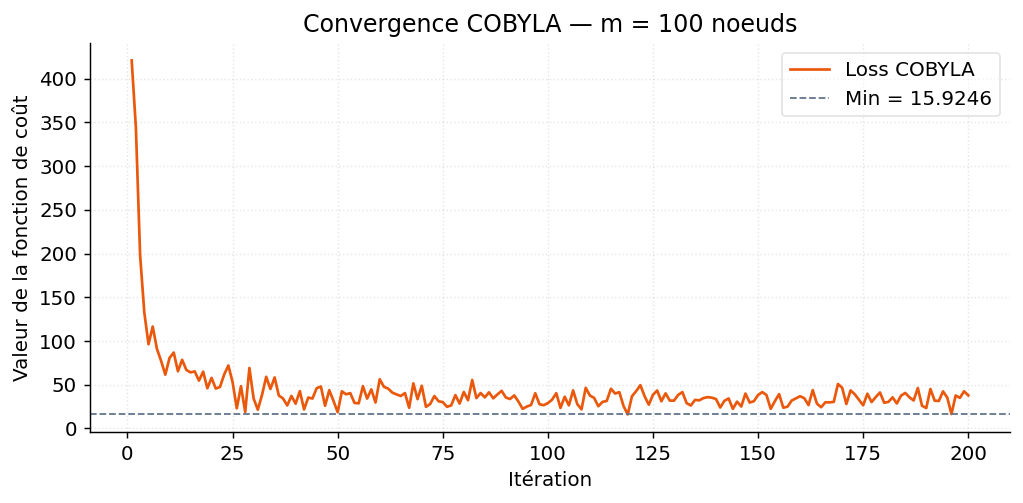

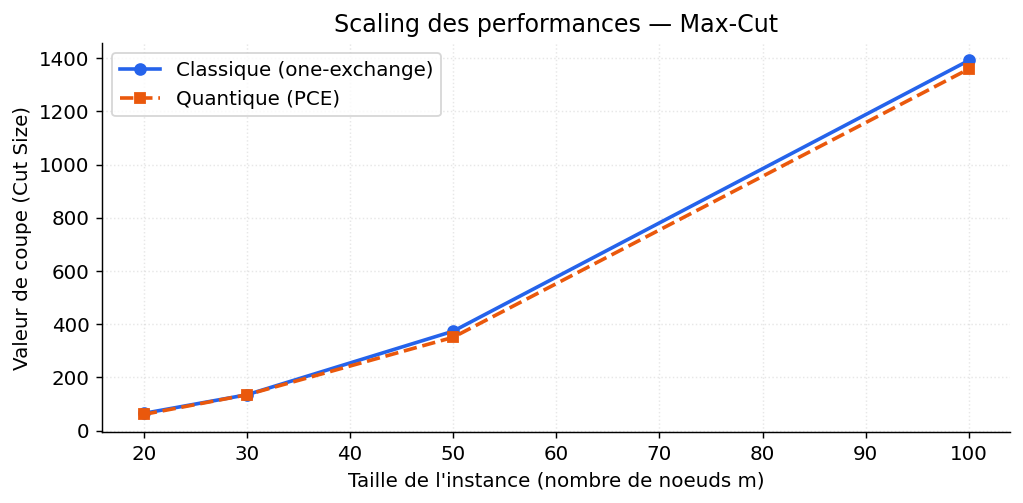

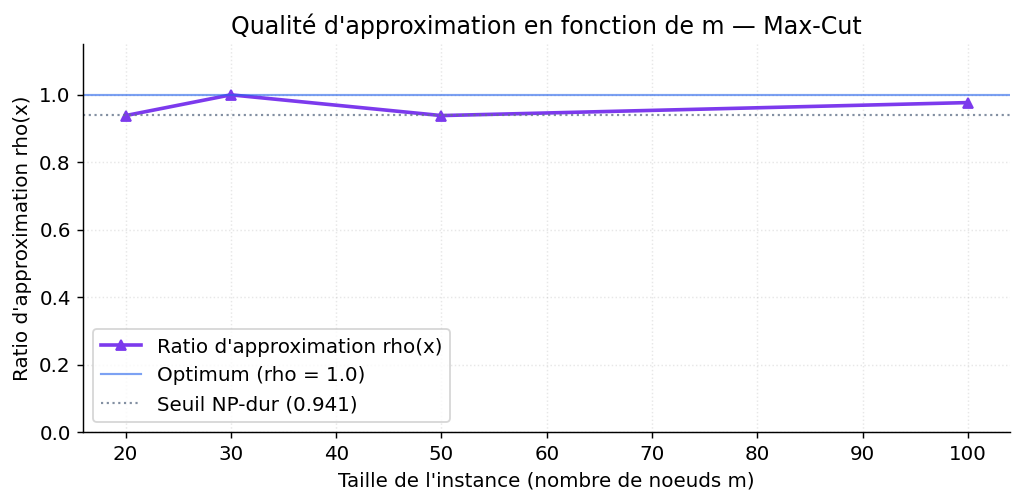

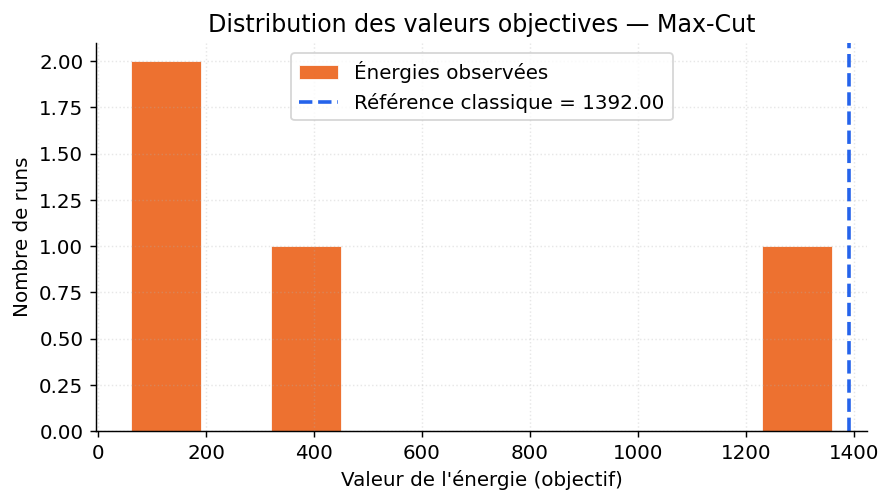

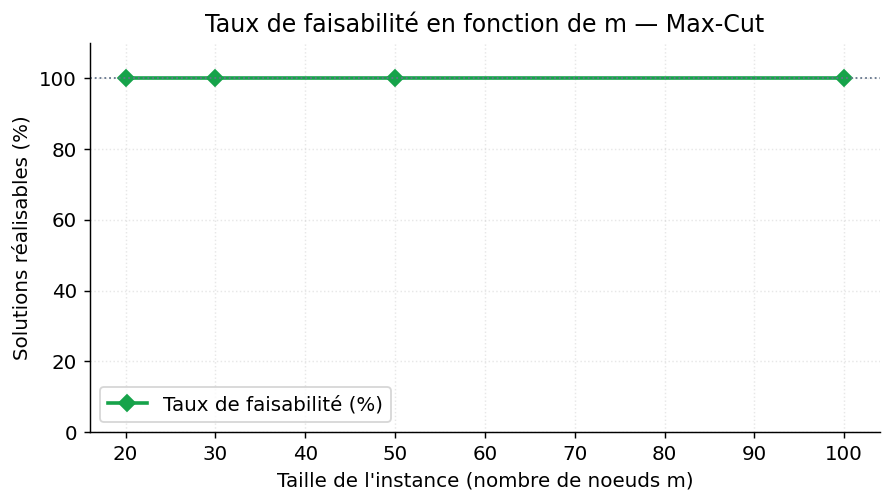

c:\Users\marti\OneDrive\Documents\CentraleSupelec\2A\ST7\Project_Orange\pauli_correlation_encoding\visualization.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


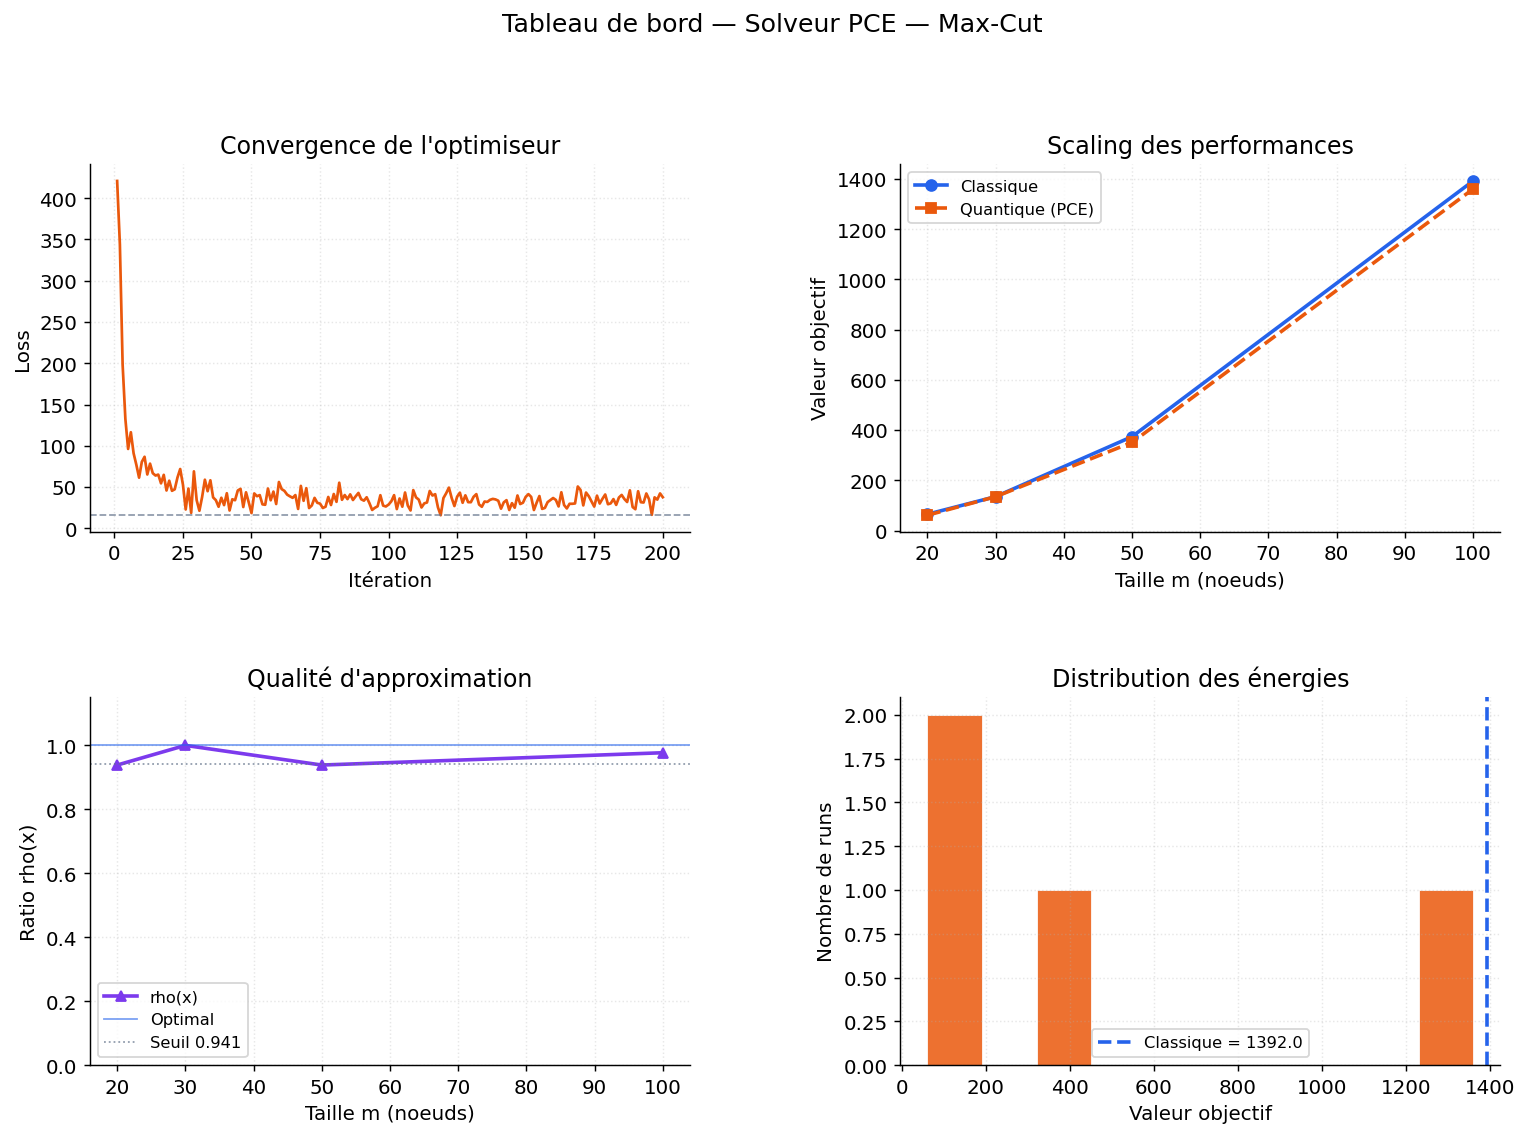

In [ ]:
# ============================================================
# CELLULE 3 : VISUALISATION
# ============================================================

# 1. Convergence (dernier run)
plot_objective_evolution(
    history_loss = q_results[-1]["history"]["loss"],
    title        = f"Convergence COBYLA — m = {sizes[-1]} noeuds",
    save_path    = "figures/convergence.png",
)

# 2. Scaling objectif
plot_performance_scaling(
    instance_sizes   = sizes,
    classical_values = c_values,
    quantum_values   = quantum_values,
    metric_name      = "Valeur de coupe (Cut Size)",
    problem_type     = problem,
    save_path        = "figures/scaling_performance.png",
)

# 3. Ratio d'approximation
plot_approximation_ratio_scaling(
    instance_sizes = sizes,
    approx_ratios  = approx_ratios,
    problem_type   = problem,
    save_path      = "figures/approximation_ratio.png",
)

# 4. Distribution des valeurs objectives
plot_energy_histogram(
    energy_values  = quantum_values,
    optimal_energy = float(max(c_values)),
    title          = f"Distribution des valeurs objectives — {problem}",
    save_path      = "figures/energy_histogram.png",
)

# 5. Taux de faisabilité
feasibility_rates = [
    sum(feasibility_flags[:i+1]) / (i+1)
    for i in range(len(feasibility_flags))
]
plot_feasibility_rate(
    instance_sizes    = sizes,
    feasibility_rates = feasibility_rates,
    problem_type      = problem,
    save_path         = "figures/feasibility_rate.png",
)

# 6. Dashboard de synthèse
plot_dashboard(
    history_loss        = q_results[-1]["history"]["loss"],
    instance_sizes      = sizes,
    classical_values    = c_values,
    quantum_values      = quantum_values,
    approx_ratios       = approx_ratios,
    energy_values       = quantum_values,
    classical_objective = float(max(c_values)),
    problem_type        = problem,
    save_path           = "figures/dashboard.png",
)